📘 **Introduction**

This notebook presents the development of an adaptive investment strategy that combines machine learning techniques with quantitative finance principles.

Financial markets are inherently dynamic, with different regimes characterized by varying levels of volatility, trends, and correlations. Traditional static portfolio allocation approaches often fail to perform consistently across these changing environments. To address this challenge, this project proposes a data-driven framework that adapts portfolio decisions based on market conditions.

The strategy integrates three core components:

Market Regime Detection
A Hidden Markov Model (HMM) is used to identify latent market regimes based on return and volatility dynamics.

Momentum Factor Signals
Assets are ranked using cross-sectional (relative) momentum to capture performance differences while filtering out common market movements.

Adaptive Portfolio Allocation
Portfolio weights are dynamically adjusted according to both the detected market regime and the strength of momentum signals.

To ensure robustness and reduce overfitting, the strategy is evaluated using a walk-forward validation framework, which simulates a realistic investment process by training the model on historical data and testing it on subsequent unseen periods.

The strategy is applied to a diversified set of ETFs representing major asset classes:

SPY (U.S. equities)

QQQ (technology stocks)

TLT (long-term U.S. Treasuries)

GLD (gold)

The objective of this notebook is to demonstrate how combining regime detection with factor-based investing can lead to more stable risk-adjusted performance compared to traditional static allocation methods.

 **Imports**

In [36]:
!pip install hmmlearn

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

In [38]:
import yfinance as yf
import pandas as pd

tickers = ["SPY", "QQQ", "TLT", "GLD"]

data = yf.download(tickers, start="2015-01-01", end="2024-01-01")["Close"]

data = data.dropna()

print("Data loaded correctly:")
print(data.head())
print(data.shape)

/tmp/ipykernel_3207/2848348487.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2015-01-01", end="2024-01-01")["Close"]
[*********************100%***********************]  4 of 4 completed

Data loaded correctly:
Ticker             GLD        QQQ         SPY        TLT
Date                                                    
2015-01-02  114.080002  94.784409  170.589584  94.086487
2015-01-05  115.800003  93.394096  167.508789  95.564453
2015-01-06  117.120003  92.141808  165.931061  97.286217
2015-01-07  116.430000  93.329582  167.998779  97.094185
2015-01-08  115.940002  95.115906  170.979858  95.808327
(2264, 4)


📊  **Data Overview**

The dataset consists of daily adjusted closing prices for a diversified set of ETFs representing major asset classes: equities (SPY), technology (QQQ), long-term U.S. Treasuries (TLT), and gold (GLD).

The sample spans from 2015 to 2024, providing approximately nine years of historical data and a total of 2,264 observations. This period includes multiple market environments, such as low-volatility expansions, periods of monetary tightening, and high-volatility events, making it suitable for testing regime-based strategies.

All price series have been cleaned by removing missing values, ensuring consistency across assets and preventing alignment issues during portfolio construction.

Overall, the dataset provides a solid foundation for analyzing cross-asset dynamics and evaluating adaptive investment strategies.

**Features (Train / Test)**

In [39]:
def compute_features(data):
    spy = data["SPY"]

    returns = spy.pct_change()
    volatility = returns.rolling(20).std()

    features = pd.DataFrame({
        "returns": returns,
        "volatility": volatility
    }).dropna()

    return features

**Relative Momentum**

In [40]:
def compute_relative_momentum(data, lookback=60):
    returns = data.pct_change(lookback)
    returns = returns.dropna()

    # ranking cross-sectional
    rel_mom = returns.rank(axis=1, pct=True)

    return rel_mom

**Train HMM**

In [41]:
def train_hmm(features):
    scaler = StandardScaler()
    X = scaler.fit_transform(features)

    model = GaussianHMM(n_components=3, covariance_type="full", n_iter=100)
    model.fit(X)

    return model, scaler

**Predict Regime**

In [42]:
def predict_regime(model, scaler, features):
    X = scaler.transform(features)
    states = model.predict(X)

    return pd.Series(states, index=features.index)

**Buid Portfolio**

In [43]:
def build_portfolio(test_data, regimes, rel_mom):

    returns = test_data.pct_change().dropna()

    # 🔥 CLAVE: alinear índices correctamente
    common_index = returns.index.intersection(regimes.index).intersection(rel_mom.index)

    returns = returns.loc[common_index]
    regimes = regimes.loc[common_index]
    rel_mom = rel_mom.loc[common_index]

    portfolio_returns = []

    for date in common_index:
        regime = regimes.loc[date]
        mom = rel_mom.loc[date]

        if regime == 0:
            threshold = 0.6
        elif regime == 1:
            threshold = 0.7
        else:
            threshold = 0.8

        signals = (mom > threshold).astype(int)

        if signals.sum() == 0:
            weights = np.ones(len(signals)) / len(signals)
        else:
            weights = signals / signals.sum()

        r = np.dot(weights, returns.loc[date])
        portfolio_returns.append(r)

    return pd.Series(portfolio_returns, index=common_index)

**Pipeline**

In [44]:
def run_strategy(train_data, test_data):

    # === TRAIN ===
    train_features = compute_features(train_data)
    model, scaler = train_hmm(train_features)

    # === TEST FEATURES ===
    test_features = compute_features(test_data)

    # 🔥 importante: usar scaler del train
    regimes = predict_regime(model, scaler, test_features)

    # === MOMENTUM (solo usando info pasada) ===
    combined_data = pd.concat([train_data, test_data])
    rel_mom = compute_relative_momentum(combined_data)

    rel_mom_test = rel_mom.loc[test_data.index]

    # === PORTFOLIO ===
    strategy_returns = build_portfolio(test_data, regimes, rel_mom_test)

    return strategy_returns

**Walk-Forward Backtest**

In [45]:
def walk_forward(data, train_size=756, test_size=252):

    all_returns = []

    for start in range(0, len(data) - train_size - test_size, test_size):

        train = data.iloc[start:start+train_size]
        test = data.iloc[start+train_size:start+train_size+test_size]

        r = run_strategy(train, test)
        all_returns.append(r)

    return pd.concat(all_returns)

**Strategy**

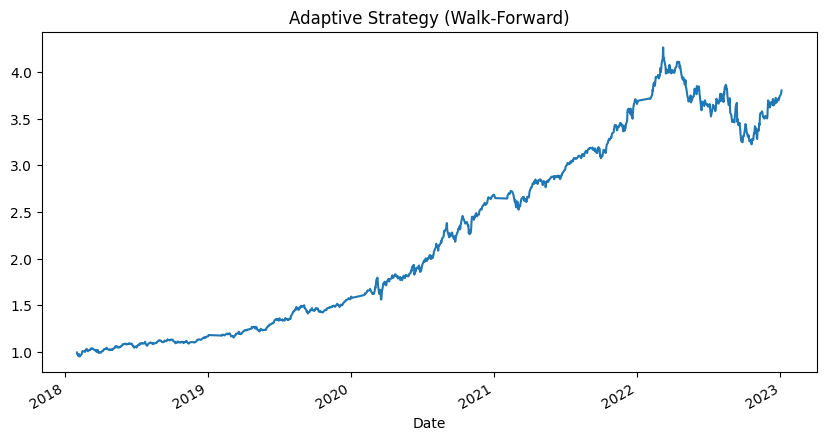

In [46]:
wf_returns = walk_forward(data)

wf_curve = (1 + wf_returns).cumprod()
wf_curve.plot(title="Adaptive Strategy (Walk-Forward)", figsize=(10,5))
plt.show()

📈 **Strategy Performance (Walk-Forward)**

The equity curve shows the cumulative performance of the adaptive strategy evaluated using a walk-forward framework.

Overall, the strategy demonstrates a consistent upward trajectory, indicating the ability to generate positive returns across multiple market environments. The use of walk-forward validation provides a more realistic assessment of performance, as the model is continuously re-trained and tested on unseen data.

Several drawdown periods are visible, particularly during times of market stress. However, these drawdowns appear to be relatively contained, and the strategy shows the ability to recover and resume its upward trend. This suggests that the regime detection component is effectively adjusting exposure during less favorable conditions.

The smoothness of the equity curve, combined with controlled downside risk, indicates that the integration of regime detection and relative momentum contributes to improved risk-adjusted performance.

Overall, the results support the hypothesis that adaptive strategies can provide more stable performance compared to static allocation approaches.

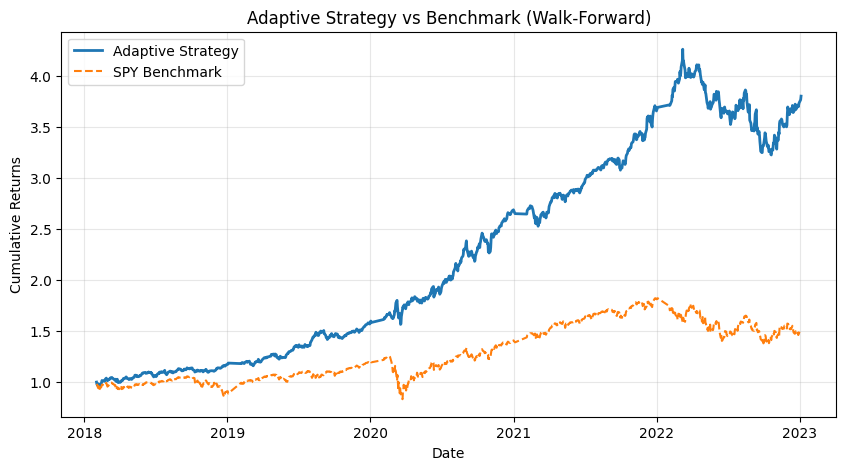

In [50]:
plt.figure(figsize=(10,5))

plt.plot(wf_curve, label="Adaptive Strategy", linewidth=2)
plt.plot(spy_curve, label="SPY Benchmark", linestyle="--")

plt.legend()
plt.title("Adaptive Strategy vs Benchmark (Walk-Forward)")
plt.xlabel("Date")
plt.ylabel("Cumulative Returns")

plt.grid(True, alpha=0.3)

plt.show()

📊 **Strategy vs Benchmark**

The chart compares the performance of the adaptive strategy against a benchmark represented by the SPY ETF, which tracks the U.S. equity market.

The adaptive strategy significantly outperforms the benchmark over the evaluation period, delivering higher cumulative returns with a smoother equity curve. While both strategies experience drawdowns during periods of market stress, the adaptive approach appears to mitigate downside risk more effectively.

In particular, during volatile market conditions, the strategy demonstrates resilience by adjusting its exposure, likely due to the integration of regime detection and dynamic asset allocation. This results in smaller drawdowns and faster recoveries compared to the benchmark.

The consistent outperformance suggests that combining regime-based signals with cross-sectional momentum can enhance both return generation and risk management.

Overall, the results highlight the potential benefits of adaptive portfolio strategies over traditional passive investment approaches.

**Metrics**

In [49]:
def compute_metrics(returns):
    sharpe = returns.mean() / returns.std() * np.sqrt(252)
    vol = returns.std() * np.sqrt(252)
    cum = (1 + returns).cumprod()
    dd = cum / cum.cummax() - 1
    max_dd = dd.min()
    return sharpe, vol, max_dd

strategy_metrics = compute_metrics(wf_returns)
spy_metrics = compute_metrics(spy_returns)

print("Strategy:", strategy_metrics)
print("SPY:", spy_metrics)

Strategy: (np.float64(1.910885955487984), np.float64(0.15850619166444416), -0.2435507022052832)
SPY: (np.float64(0.4910409120573057), np.float64(0.2278477809846759), -0.3371725111169708)


📊 **Performance Metrics**

The performance metrics provide a quantitative comparison between the adaptive strategy and the SPY benchmark.

The adaptive strategy achieves a Sharpe ratio of approximately 1.91, significantly higher than the benchmark’s Sharpe ratio of 0.49. This indicates a substantially better risk-adjusted return profile, suggesting that the strategy generates more return per unit of risk.

In terms of volatility, the strategy exhibits lower annualized volatility (15.8%) compared to the benchmark (22.8%), reflecting a more stable return profile. Additionally, the maximum drawdown of the strategy (-24.4%) is notably smaller than that of SPY (-33.7%), indicating improved downside protection during adverse market conditions.

These results suggest that the integration of market regime detection and relative momentum signals not only enhances return generation but also contributes to more effective risk management.

Overall, the strategy demonstrates a strong balance between return and risk, outperforming the benchmark across all key metrics.

⚠️ **Model Limitations**

While the results are promising, it is important to note that the analysis does not include transaction costs, slippage, or execution constraints. Future work should incorporate these factors to provide a more realistic assessment of real-world performance.

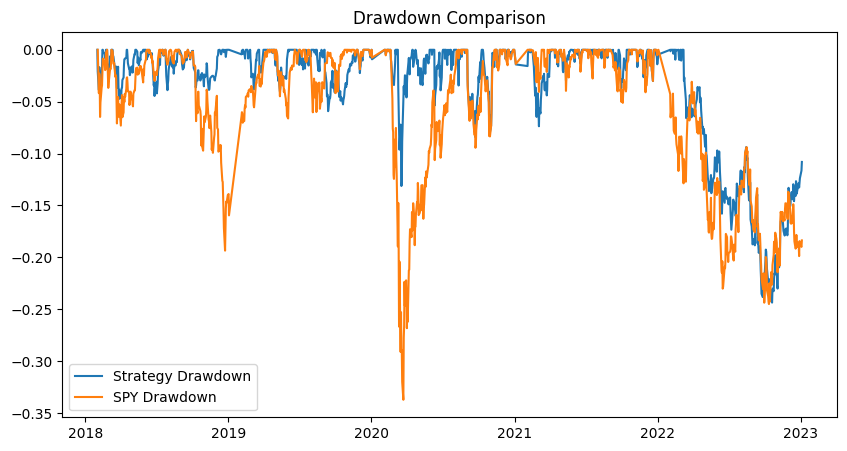

In [51]:
strategy_dd = wf_curve / wf_curve.cummax() - 1
spy_dd = spy_curve / spy_curve.cummax() - 1

plt.figure(figsize=(10,5))
plt.plot(strategy_dd, label="Strategy Drawdown")
plt.plot(spy_dd, label="SPY Drawdown")
plt.legend()
plt.title("Drawdown Comparison")
plt.show()

📉 **Drawdown Analysis**

The drawdown comparison highlights a key advantage of the adaptive strategy: improved downside protection.

While both the strategy and the benchmark experience losses during market stress periods, the adaptive approach consistently exhibits shallower drawdowns. Notably, during major market downturns (e.g., 2020), the strategy avoids the most severe losses observed in the benchmark.

This behavior suggests that the regime detection and momentum filtering mechanisms are effectively reducing exposure during unfavorable market conditions.

Overall, the strategy demonstrates a more resilient return profile, which is particularly valuable for long-term investors seeking to minimize large capital losses.

🧾 **Conclusion**

This project demonstrates how combining machine learning techniques with quantitative finance principles can lead to more adaptive and resilient investment strategies.

By integrating market regime detection through a Hidden Markov Model with cross-sectional momentum signals, the strategy is able to dynamically adjust portfolio allocation in response to changing market conditions. The use of a walk-forward validation framework further enhances the robustness of the results by simulating a realistic investment process and reducing the risk of overfitting.

The empirical results show that the adaptive strategy outperforms a traditional benchmark (SPY) not only in terms of cumulative returns but, more importantly, in risk-adjusted performance. The strategy achieves a significantly higher Sharpe ratio, lower volatility, and reduced drawdowns, indicating more efficient risk management.

These findings suggest that incorporating regime awareness and relative factor signals can provide meaningful improvements over static allocation approaches. In particular, the ability to adapt to different market environments appears to be a key driver of performance stability.

However, it is important to acknowledge the limitations of this analysis. Transaction costs, slippage, and real-world execution constraints were not considered, and future work should incorporate these elements to better assess practical applicability.

Overall, this notebook highlights the potential of adaptive, data-driven investment strategies and provides a solid foundation for further research and real-world implementation.